---

# Homework 4

**Course:** CSCE-636-700

**Instructor:** Dr. Anxiao Jiang

**Author:** Brody Jordan (431005357)

---

 ## Problem 1

Check out the Jupyter notebook for Chapter 8 at https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/chapter08_image-classification.ipynb. It uses the convolutional base of an Xception model for an image classification task (which is on the "dogs-vs-cats" dataset), and also tries fine tuning. Your task: use another existing trained neural network (which is different from Xception, such as ResNet, etc.) for the same task, and also try fine tuning. Submit your complete code, draw figures on the training/validation performance, and show the testing performance.

---

I began by loading the dataset as done in the textbook, then augmented the data with random flips, rotations, and zooms.

I then loaded a pretrained model. I chose "resnet_v2_50_imagenet" from https://keras.io/keras_hub/presets/ since it was recommended and it has a close number of layers. xception is a 41-layer model pre-trained on ImageNet1k, and resnet_v2_50_imagenet is a 50-layer model, also pre-trained on ImageNet1k.

All of the performance figures for training, validation, and testing are shown below, for both the initial network and the fine-tuned network! :)

In [1]:
import kagglehub

kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import numpy as np
import matplotlib.pyplot as plt
import zipfile
import shutil, pathlib

download_path = kagglehub.competition_download("dogs-vs-cats")

with zipfile.ZipFile(download_path + "/train.zip", "r") as zip_ref:
    zip_ref.extractall(".")

original_dir = pathlib.Path("train")
new_base_dir = pathlib.Path("dogs_vs_cats_small")

def make_subset(subset_name, start_index, end_index):
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category
        os.makedirs(dir)
        fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(src=original_dir / fname, dst=dir / fname)

make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test", start_index=1500, end_index=2500)

100%|██████████| 812M/812M [00:37<00:00, 22.5MB/s]

Extracting files...


Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


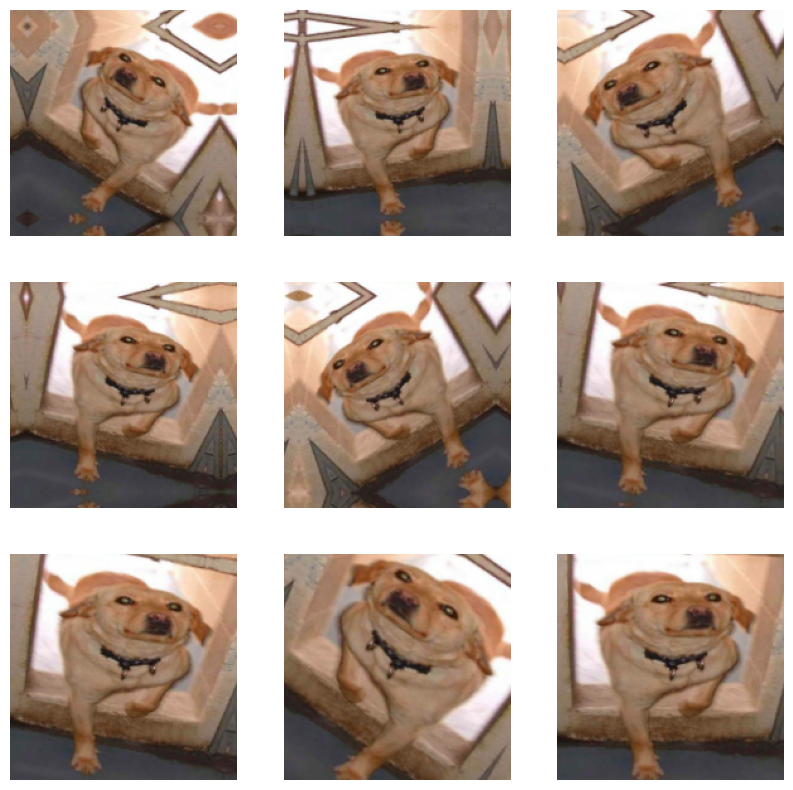

In [3]:
import keras
from keras import layers
import tensorflow as tf
from keras.utils import image_dataset_from_directory

batch_size = 64
image_size = (180, 180)
train_dataset = image_dataset_from_directory(
    new_base_dir / "train", image_size=image_size, batch_size=batch_size
)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation", image_size=image_size, batch_size=batch_size
)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test", image_size=image_size, batch_size=batch_size
)

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
]

def data_augmentation(images, targets):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images, targets

augmented_train_dataset = train_dataset.map(
    data_augmentation, num_parallel_calls=8
)
augmented_train_dataset = augmented_train_dataset.prefetch(tf.data.AUTOTUNE)

plt.figure(figsize=(10, 10))
for image_batch, _ in train_dataset.take(1):
    image = image_batch[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image, _ = data_augmentation(image, None)
        augmented_image = keras.ops.convert_to_numpy(augmented_image)
        plt.imshow(augmented_image.astype("uint8"))
        plt.axis("off")


In [4]:
import keras_hub

conv_base = keras_hub.models.Backbone.from_preset(
    "resnet_v2_50_imagenet",
    trainable=False,
)

preprocessor = keras_hub.layers.ImageConverter.from_preset(
    "resnet_v2_50_imagenet",
    image_size=(180, 180),
)

inputs = keras.Input(shape=(180, 180, 3))
x = preprocessor(inputs)
x = conv_base(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction_new.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    augmented_train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks,
)


Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.8467 - loss: 0.3324 - val_accuracy: 0.9220 - val_loss: 0.2155
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 116ms/step - accuracy: 0.9529 - loss: 0.1120 - val_accuracy: 0.9710 - val_loss: 0.0724
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.9851 - loss: 0.0420 - val_accuracy: 0.9800 - val_loss: 0.0574
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.9901 - loss: 0.0300 - val_accuracy: 0.9700 - val_loss: 0.0995
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.9852 - loss: 0.0470 - val_accuracy: 0.9540 - val_loss: 0.1606
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9596 - loss: 0.1045 - val_accuracy: 0.9710 - val_loss: 0.0724
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.9855 - loss: 0.0367 - val_accuracy: 0.9720 - val_loss: 0.0750
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.9851 - loss: 0.0335 - val_accuracy: 0.9680 -

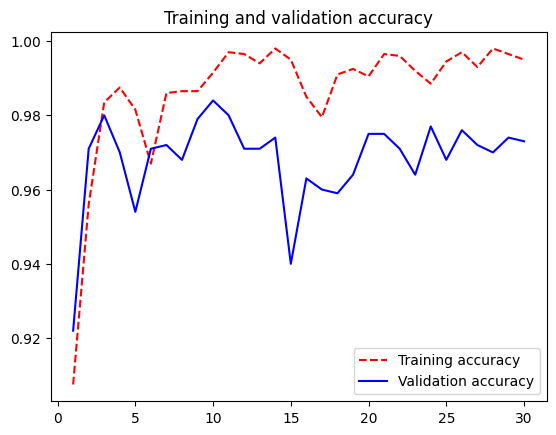

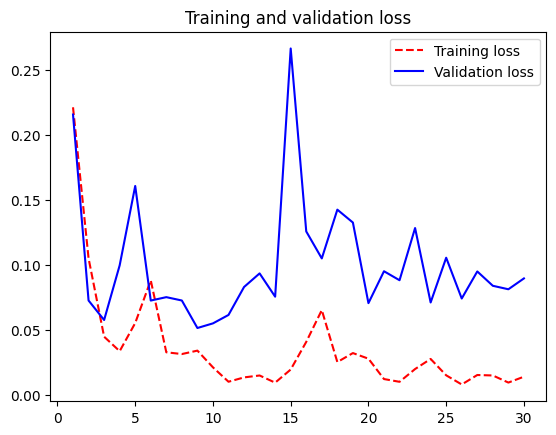

In [5]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [7]:
test_model = keras.models.load_model("feature_extraction_new.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - accuracy: 0.9780 - loss: 0.0631
Test accuracy: 0.980


---

## Fine tuning

---

In [8]:
conv_base.trainable = True

model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning_new.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    augmented_train_dataset,
    epochs=10,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9966 - loss: 0.0087 - val_accuracy: 0.9740 - val_loss: 0.0867
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 113ms/step - accuracy: 0.9963 - loss: 0.0106 - val_accuracy: 0.9730 - val_loss: 0.0842
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.9935 - loss: 0.0133 - val_accuracy: 0.9750 - val_loss: 0.0834
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.9953 - loss: 0.0131 - val_accuracy: 0.9750 - val_loss: 0.0786
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.9916 - loss: 0.0154 - val_accuracy: 0.9740 - val_loss: 0.0798
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.9979 - loss: 0.0074 - val_accuracy: 0.9760 - val_loss: 0.0847
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.9959 - loss: 0.0098 - val_accuracy: 0.9740 - val_loss: 0.0806
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.9979 - loss: 0.0055 - val_accuracy: 0.9740 

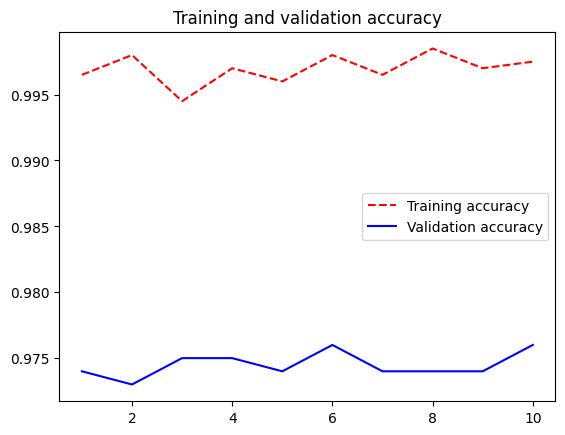

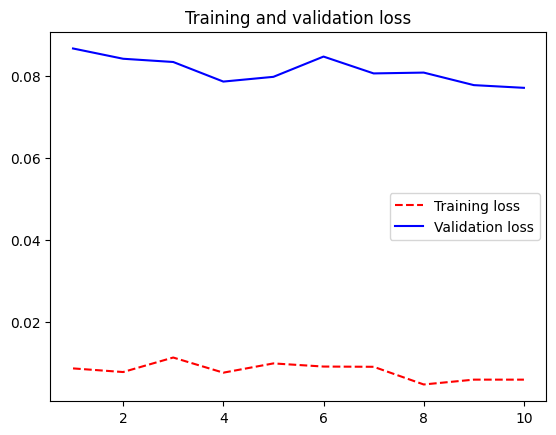

In [9]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [10]:
tuned_model = keras.models.load_model("fine_tuning_new.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9795 - loss: 0.0561
Test accuracy: 0.980
